# System 303 v3 near-completion shrinkage

Use the full banded Cholesky basis and its last `n-m` omitted directions to evaluate the v3 operation: take the coordinate hull first, then intersect it with the initial box. Only the all-coordinate shrinkage percentages and histogram are retained.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import cholesky_banded, solveh_banded
from scipy.linalg.lapack import get_lapack_funcs


data_dir = Path("system_303")
A_full = np.genfromtxt(data_dir / "stiffness_beam_A.dat", delimiter=",")
b_full = np.genfromtxt(data_dir / "forcing_b.dat")
initial_box_full = np.genfromtxt(data_dir / "B0_wide_bc.dat", delimiter=",")
stored_solution_full = np.genfromtxt(data_dir / "soln_x.dat")

# Remove the first three boundary-condition coordinates, as in the existing 303 notebooks.
A = A_full[3:, 3:]
b = b_full[3:]
initial_box = initial_box_full[3:]
stored_solution = stored_solution_full[3:]
n = b.size

diagonal = np.diag(A)
if np.any(diagonal <= 0):
    raise ValueError("Jacobi scaling requires a positive diagonal.")
scale = np.sqrt(diagonal)
A_hat = A / scale[:, None] / scale[None, :]
b_hat = b / scale

rows, columns = np.nonzero(A_hat)
bandwidth = int(np.max(rows - columns))
A_banded = np.zeros((bandwidth + 1, n), dtype=float)
for offset in range(bandwidth + 1):
    A_banded[offset, : n - offset] = np.diag(A_hat, k=-offset)

L_banded = cholesky_banded(A_banded, lower=True, check_finite=False)
y_star = solveh_banded(A_banded, b_hat, lower=True, check_finite=False)
x_star = y_star / scale
outside_original_box = (x_star < initial_box[:, 0]) | (x_star > initial_box[:, 1])
effective_box = np.column_stack([
    np.minimum(initial_box[:, 0], x_star),
    np.maximum(initial_box[:, 1], x_star),
])
lower0 = scale * effective_box[:, 0]
upper0 = scale * effective_box[:, 1]
center0 = 0.5 * (lower0 + upper0)
radius0 = 0.5 * (upper0 - lower0)

print(f"system dimension n: {n:,}")
print(f"scaled bandwidth: {bandwidth}")
print(f"independent Cholesky directions: {np.count_nonzero(L_banded[0] > 0):,}")
print(f"coordinates expanded to contain the solution: {outside_original_box.sum():,}")
print(f"relative difference from stored solution: {np.linalg.norm(x_star - stored_solution) / np.linalg.norm(x_star):.3e}")

system dimension n: 300
scaled bandwidth: 4
independent Cholesky directions: 300
coordinates expanded to contain the solution: 0
relative difference from stored solution: 1.241e-07


In [2]:
omitted_counts = np.arange(0, 101, 10, dtype=int)
m_values = n - omitted_counts
max_omitted = int(omitted_counts[-1])
tail_start = n - max_omitted

# P = L^{-T}. Only its final 100 columns are needed.
LT_banded = np.zeros_like(L_banded)
for offset in range(bandwidth + 1):
    LT_banded[bandwidth - offset, offset:] = L_banded[offset, : n - offset]

tail_rhs = np.zeros((n, max_omitted), dtype=float, order="F")
tail_rhs[tail_start:, :] = np.eye(max_omitted)
tbtrs = get_lapack_funcs("tbtrs", (LT_banded, tail_rhs))
P_tail, info = tbtrs(
    LT_banded, tail_rhs, uplo="U", trans="N", diag="N", overwrite_b=1
)
if info != 0:
    raise RuntimeError(f"LAPACK triangular band solve failed with info={info}.")


def hull_then_intersect(omitted):
    """Return v3 bounds for m=n-omitted using the complementary tail projector."""
    if omitted == 0:
        return y_star.copy(), y_star.copy()

    start = n - omitted
    P = P_tail[:, max_omitted - omitted :]
    Pi = P * L_banded[0, start:][None, :]
    for offset in range(1, bandwidth + 1):
        Pi[:, offset:] += (
            P[:, : omitted - offset]
            * L_banded[offset, start : start + omitted - offset][None, :]
        )

    projected_center = y_star + Pi @ (center0[start:] - y_star[start:])
    projected_radius = np.abs(Pi) @ radius0[start:]
    hull_lower = projected_center - projected_radius
    hull_upper = projected_center + projected_radius
    lower = np.maximum(lower0, hull_lower)
    upper = np.minimum(upper0, hull_upper)
    if np.any(lower > upper):
        raise RuntimeError("Roundoff produced an empty coordinate intersection.")
    return lower, upper


initial_width = upper0 - lower0
shrinkage_pct = np.empty((len(omitted_counts), n), dtype=float)
for row, omitted in enumerate(omitted_counts):
    lower, upper = hull_then_intersect(int(omitted))
    shrinkage_pct[row] = np.clip(
        100.0 * (1.0 - (upper - lower) / initial_width), 0.0, 100.0
    )

if not np.all(shrinkage_pct[0] == 100.0):
    raise AssertionError("The m=n enclosure did not contract to degeneracy.")

quantile_levels = np.array([0.0, 0.10, 0.25, 0.50, 0.75, 0.90, 1.0])
quantiles = np.quantile(shrinkage_pct, quantile_levels, axis=1).T
print("Shrinkage across all coordinates (%)")
print("m       omitted    mean    median     min     p10     p90     max")
for m, omitted, values, qs in zip(m_values, omitted_counts, shrinkage_pct, quantiles):
    print(
        f"{m:5d}   {omitted:7d}   {values.mean():6.2f}   {np.median(values):6.2f}"
        f"   {qs[0]:6.2f}  {qs[1]:6.2f}  {qs[5]:6.2f}  {qs[6]:6.2f}"
    )

results_dir = Path("system_303_to_completion_results")
results_dir.mkdir(exist_ok=True)
np.savez_compressed(
    results_dir / "v3_shrinkage_percentages.npz",
    n=n,
    m_values=m_values,
    omitted_counts=omitted_counts,
    shrinkage_pct=shrinkage_pct,
    expanded_coordinate_count=outside_original_box.sum(),
)

Shrinkage across all coordinates (%)
m       omitted    mean    median     min     p10     p90     max
  300         0   100.00   100.00   100.00  100.00  100.00  100.00
  290        10    53.56    55.10     0.00    1.65   96.52   99.99
  280        20    52.02    52.69     0.00    0.00   96.33   99.99
  270        30    49.89    48.92     0.00    0.00   96.02   99.99
  260        40    47.08    43.30     0.00    0.00   95.44   99.99
  250        50    45.36    39.44     0.00    0.00   95.09   99.99
  240        60    43.02    33.43     0.00    0.00   94.62   99.99
  230        70    39.97    26.40     0.00    0.00   94.01   99.98
  220        80    37.98    21.54     0.00    0.00   93.38   99.98
  210        90    35.48    13.88     0.00    0.00   92.40   99.98
  200       100    32.59     3.51     0.00    0.00   91.20   99.97


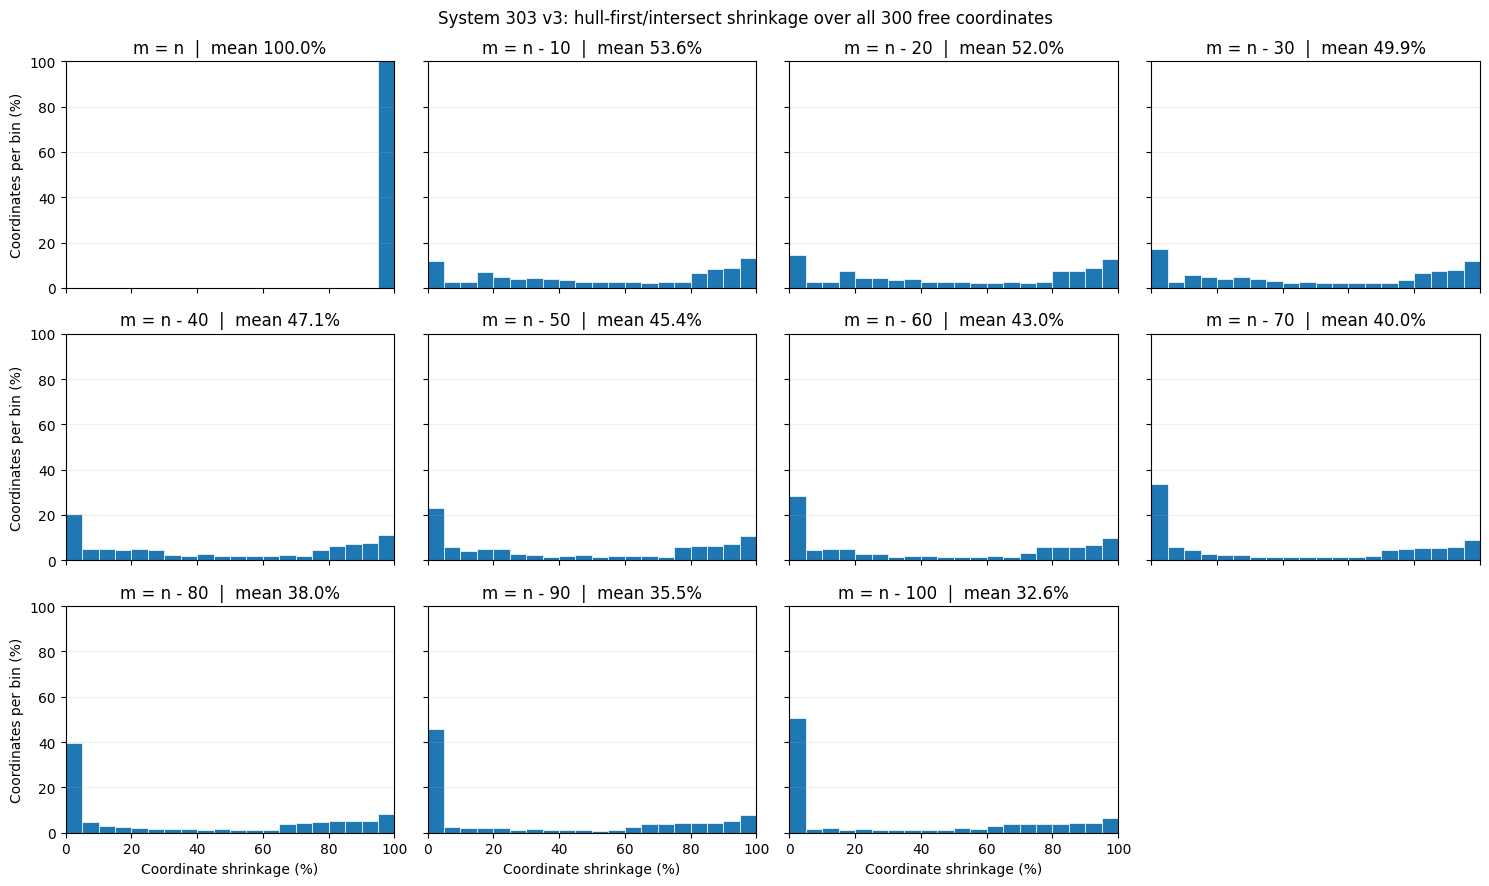

saved system_303_to_completion_results/v3_shrinkage_histogram.png


In [3]:
bins = np.linspace(0.0, 100.0, 21)
fig, axes = plt.subplots(3, 4, figsize=(15, 9), sharex=True, sharey=True)
for ax, m, omitted, values in zip(axes.ravel(), m_values, omitted_counts, shrinkage_pct):
    ax.hist(
        values, bins=bins, weights=np.full(n, 100.0 / n),
        color="tab:blue", edgecolor="white", linewidth=0.5,
    )
    label = "m = n" if omitted == 0 else f"m = n - {omitted:,}"
    ax.set_title(f"{label}  |  mean {values.mean():.1f}%")
    ax.grid(axis="y", alpha=0.2)

axes.ravel()[-1].remove()
for ax in axes[-1, :3]:
    ax.set_xlabel("Coordinate shrinkage (%)")
for ax in axes[:, 0]:
    ax.set_ylabel("Coordinates per bin (%)")
for ax in axes.ravel()[:-1]:
    ax.set_xlim(0.0, 100.0)
    ax.set_ylim(0.0, 100.0)

fig.suptitle("System 303 v3: hull-first/intersect shrinkage over all 300 free coordinates")
fig.tight_layout()
figure_path = results_dir / "v3_shrinkage_histogram.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"saved {figure_path}")